<a href="https://colab.research.google.com/github/bhamees79-alt/SIH_PROJECT/blob/main/Temporal_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import os

VIDEO_DIR = "/content/drive/MyDrive/Sih_videos"

files = os.listdir(VIDEO_DIR)

print("Number of files:", len(files))

print(files[:10])

Number of files: 117
['incorrect4.mp4', 'correct9.mp4', 'incorrect3.mp4', 'skipped4.mp4', 'correct8.mp4', 'Hesitation 1.mp4', 'Skip 3.mp4', 'Skip 2.mp4', 'Correct 7.mp4', 'incorr.mp4']


In [37]:
import pandas as pd
import os

PROJECT_DIR = "/content/drive/MyDrive/BAS_HAR_SIH"

ANNOTATION_FILE = os.path.join(
    PROJECT_DIR,
    "annotations",
    "step_annotations.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "har_dataset"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(ANNOTATION_FILE)

print(df.shape)
display(df.head())

(759, 9)


,video_id,step_id,step_name,start_time_sec,end_time_sec,status,notes,Unnamed: 7,Unnamed: 8
0,V001,1,RETRIEVE_COTTON,0.4,1.2,observed,NaN,NaN,NaN
1,V001,2,PLACE_COTTON,1.2,2.2,observed,NaN,NaN,NaN
2,V001,3,HANDLE_SEEDS,2.5,3.5,observed,NaN,NaN,NaN
3,V001,4,PLACE_SEEDS,3.5,4.9,observed,NaN,NaN,NaN
4,V001,5,TAKE_DROPPER,5.0,5.9,observed,NaN,NaN,NaN


In [38]:
print(df.columns.tolist())
VIDEO_COL = "video_id"
STEP_COL = "step_id"
ACTIVITY_COL = "step_name"
START_COL = "start_time_sec"
END_COL = "end_time_sec"

['video_id', 'step_id', 'step_name', 'start_time_sec', 'end_time_sec', 'status', 'notes', 'Unnamed: 7', 'Unnamed: 8']


In [39]:
import cv2
import glob
import os

video_extensions = [
    "*.mp4",
    "*.avi",
    "*.mov",
    "*.mkv"
]

video_paths = {}

for extension in video_extensions:
    paths = glob.glob(
        os.path.join(VIDEO_DIR, extension)
    )

    for path in paths:
        filename = os.path.basename(path)
        video_id = os.path.splitext(filename)[0]

        video_paths[video_id] = path

print("Videos found:", len(video_paths))

print(list(video_paths.keys())[:10])

Videos found: 117
['incorrect4', 'correct9', 'incorrect3', 'skipped4', 'correct8', 'Hesitation 1', 'Skip 3', 'Skip 2', 'Correct 7', 'incorr']


In [40]:
video_metadata = {}

for video_id, path in video_paths.items():

    cap = cv2.VideoCapture(path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    duration = (
        total_frames / fps
        if fps > 0
        else 0
    )

    cap.release()

    video_metadata[video_id] = {
        "fps": fps,
        "total_frames": total_frames,
        "width": width,
        "height": height,
        "duration": duration
    }

In [41]:
for video_id, info in list(video_metadata.items())[:5]:

    print(video_id)
    print(info)
    print()

incorrect4
{'fps': 30.005260515952006, 'total_frames': 443, 'width': 1920, 'height': 1080, 'duration': 14.764077777777779}

correct9
{'fps': 30.096845370532787, 'total_frames': 326, 'width': 1080, 'height': 1920, 'duration': 10.8317}

incorrect3
{'fps': 30.06275648780337, 'total_frames': 518, 'width': 1920, 'height': 1080, 'duration': 17.230622222222223}

skipped4
{'fps': 30.00522904815478, 'total_frames': 526, 'width': 1920, 'height': 1080, 'duration': 17.530277777777776}

correct8
{'fps': 30.06460096196076, 'total_frames': 502, 'width': 1920, 'height': 1080, 'duration': 16.697377777777778}



In [42]:
segments = []

for _, row in df.iterrows():

    video_id = str(row[VIDEO_COL])

    if video_id not in video_metadata:
        print("Video not found:", video_id)
        continue

    fps = video_metadata[video_id]["fps"]

    start_time = float(row[START_COL])
    end_time = float(row[END_COL])

    start_frame = int(
        round(start_time * fps)
    )

    end_frame = int(
        round(end_time * fps)
    )

    total_frames = video_metadata[
        video_id
    ]["total_frames"]

    start_frame = max(
        0,
        start_frame
    )

    end_frame = min(
        total_frames - 1,
        end_frame
    )

    segments.append({
        "video_id": video_id,
        "step_id": row[STEP_COL],
        "activity": row[ACTIVITY_COL],
        "start_time_sec": start_time,
        "end_time_sec": end_time,
        "start_frame": start_frame,
        "end_frame": end_frame,
        "fps": fps,
        "status": row.get("status", ""),
        "notes": row.get("notes", "")
    })

segments_df = pd.DataFrame(segments)

Video not found: V001
Video not found: V001
Video not found: V001
Video not found: V001
Video not found: V001
Video not found: V001
Video not found: V002
Video not found: V002
Video not found: V002
Video not found: V002
Video not found: V002
Video not found: V002
Video not found: V003
Video not found: V003
Video not found: V003
Video not found: V003
Video not found: V003
Video not found: V003
Video not found: V004
Video not found: V004
Video not found: V004
Video not found: V004
Video not found: V004
Video not found: V004
Video not found: V005
Video not found: V005
Video not found: V005
Video not found: V005
Video not found: V005
Video not found: V005
Video not found: V006
Video not found: V006
Video not found: V006
Video not found: V006
Video not found: V006
Video not found: V006
Video not found: V007
Video not found: V007
Video not found: V007
Video not found: V007
Video not found: V007
Video not found: V007
Video not found: V008
Video not found: V008
Video not found: V008
Video not 

In [43]:
import os

VIDEO_DIR = "/content/drive/MyDrive/Sih_videos"

print("VIDEO_DIR:")
print(VIDEO_DIR)

print("\nDoes this folder exist?")
print(os.path.exists(VIDEO_DIR))

if os.path.exists(VIDEO_DIR):

    files = os.listdir(VIDEO_DIR)

    print("\nNumber of files:")
    print(len(files))

    print("\nFirst 50 files:")

    for f in files[:50]:
        print(f)

VIDEO_DIR:
/content/drive/MyDrive/Sih_videos

Does this folder exist?
True

Number of files:
117

First 50 files:
incorrect4.mp4
correct9.mp4
incorrect3.mp4
skipped4.mp4
correct8.mp4
Hesitation 1.mp4
Skip 3.mp4
Skip 2.mp4
Correct 7.mp4
incorr.mp4
corr.mp4
correct1.mp4
skipped.mp4
correct.mp4
incorrect step.mp4
correct video 1.mp4
correct video.mp4
corr1.mp4
C7.mp4
C6.mp4
C5.mp4
S4.mp4
I4.mp4
C4.mp4
s3.mp4
I3.mp4
c3.mp4
s2.mp4
I2.mp4
c2.mp4
s1.mp4
I1.mp4
c1.mp4
c8.mp4
c9.mp4
c10.mp4
c11.mp4
c12.mp4
c13.mp4
c14.mp4
c15.mp4
c16.mp4
c17.mp4
c18.mp4
c19.mp4
c20.mp4
s5.mp4
s6.mp4
s7.mp4
I5.mp4


In [44]:
print("Video IDs from CSV:")

for video_id in df["video_id"].unique()[:30]:
    print(video_id)

print("\nActual video filenames:")

for f in files[:30]:
    print(f)

Video IDs from CSV:
V001
V002
V003
V004
V005
V006
V007
V008
V009
V010
V011
V012
V013
V014
V015
V016
V017
V018
V019
V020
V021
V022
V023
V024
V025
V026
V027
V028
V029
V030

Actual video filenames:
incorrect4.mp4
correct9.mp4
incorrect3.mp4
skipped4.mp4
correct8.mp4
Hesitation 1.mp4
Skip 3.mp4
Skip 2.mp4
Correct 7.mp4
incorr.mp4
corr.mp4
correct1.mp4
skipped.mp4
correct.mp4
incorrect step.mp4
correct video 1.mp4
correct video.mp4
corr1.mp4
C7.mp4
C6.mp4
C5.mp4
S4.mp4
I4.mp4
C4.mp4
s3.mp4
I3.mp4
c3.mp4
s2.mp4
I2.mp4
c2.mp4


In [45]:
import os

VIDEO_DIR = "/content/drive/MyDrive/Sih_videos"

video_files = sorted([
    f for f in os.listdir(VIDEO_DIR)
    if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))
])

print("Total videos:", len(video_files))

for i, f in enumerate(video_files, start=1):
    print(f"{i:03d}  ->  {f}")

Total videos: 117
001  ->  C4.mp4
002  ->  C5.mp4
003  ->  C6.mp4
004  ->  C7.mp4
005  ->  Correct 7.mp4
006  ->  Hesitation 1.mp4
007  ->  I1.mp4
008  ->  I12.mp4
009  ->  I2.mp4
010  ->  I3.mp4
011  ->  I4.mp4
012  ->  I5.mp4
013  ->  S4.mp4
014  ->  Skip 2.mp4
015  ->  Skip 3.mp4
016  ->  c1.mp4
017  ->  c10.mp4
018  ->  c11.mp4
019  ->  c12.mp4
020  ->  c13.mp4
021  ->  c14.mp4
022  ->  c15.mp4
023  ->  c16.mp4
024  ->  c17.mp4
025  ->  c18.mp4
026  ->  c19.mp4
027  ->  c2.mp4
028  ->  c20.mp4
029  ->  c21.mp4
030  ->  c22.mp4
031  ->  c23.mp4
032  ->  c24.mp4
033  ->  c25.mp4
034  ->  c26.mp4
035  ->  c27.mp4
036  ->  c28.mp4
037  ->  c3.mp4
038  ->  c8.mp4
039  ->  c9.mp4
040  ->  corr.mp4
041  ->  corr1.mp4
042  ->  correct video 1.mp4
043  ->  correct video.mp4
044  ->  correct.mp4
045  ->  correct1.mp4
046  ->  correct8.mp4
047  ->  correct9.mp4
048  ->  do1.mp4
049  ->  do10.mp4
050  ->  do11.mp4
051  ->  do12.mp4
052  ->  do13.mp4
053  ->  do2.mp4
054  ->  do3.mp4
055  ->  d

In [46]:
import os

ANNOTATION_DIR = "/content/drive/MyDrive/BAS_HAR_SIH/annotations"

print("Files in annotations folder:")
for f in os.listdir(ANNOTATION_DIR):
    print(f)

Files in annotations folder:
metadata.csv
step_annotations.csv


In [47]:
import pandas as pd

ANNOTATION_DIR = "/content/drive/MyDrive/BAS_HAR_SIH/annotations"

step_file = os.path.join(
    ANNOTATION_DIR,
    "step_annotations.csv"
)

metadata_file = os.path.join(
    ANNOTATION_DIR,
    "metadata.csv"
)

steps_df = pd.read_csv(step_file)
metadata_df = pd.read_csv(metadata_file)

print("Step annotation shape:", steps_df.shape)
print("Metadata shape:", metadata_df.shape)

print("\nStep annotation columns:")
print(steps_df.columns.tolist())

print("\nMetadata columns:")
print(metadata_df.columns.tolist())

Step annotation shape: (759, 9)
Metadata shape: (117, 4)

Step annotation columns:
['video_id', 'step_id', 'step_name', 'start_time_sec', 'end_time_sec', 'status', 'notes', 'Unnamed: 7', 'Unnamed: 8']

Metadata columns:
['video_id', 'filename', 'behavior', 'variation']


In [48]:
print(metadata_df.head(20))

   video_id filename behavior variation
0      V001   c1.mp4  correct      none
1      V002  c10.mp4  correct      none
2      V003  c11.mp4  correct      none
3      V004  c12.mp4  correct      none
4      V005  c13.mp4  correct      none
5      V006  c14.mp4  correct      none
6      V007  c15.mp4  correct      none
7      V008  c16.mp4  correct      none
8      V009  c17.mp4  correct      none
9      V010  c18.mp4  correct      none
10     V011  c19.mp4  correct      none
11     V012   c2.mp4  correct      none
12     V013  c20.mp4  correct      none
13     V014  c21.mp4  correct      none
14     V015  c22.mp4  correct      none
15     V016  c23.mp4  correct      none
16     V017  c24.mp4  correct      none
17     V018  c25.mp4  correct      none
18     V019  c26.mp4  correct      none
19     V020  c27.mp4  correct      none


In [49]:
merged_df = steps_df.merge(
    metadata_df[["video_id", "filename", "behavior", "variation"]],
    on="video_id",
    how="left"
)

print("Merged shape:", merged_df.shape)

print("\nFirst 10 rows:")
display(merged_df.head(10))

Merged shape: (759, 12)

First 10 rows:


,video_id,step_id,step_name,start_time_sec,end_time_sec,status,notes,Unnamed: 7,Unnamed: 8,filename,behavior,variation
0,V001,1,RETRIEVE_COTTON,0.4,1.2,observed,NaN,NaN,NaN,c1.mp4,correct,none
1,V001,2,PLACE_COTTON,1.2,2.2,observed,NaN,NaN,NaN,c1.mp4,correct,none
2,V001,3,HANDLE_SEEDS,2.5,3.5,observed,NaN,NaN,NaN,c1.mp4,correct,none
3,V001,4,PLACE_SEEDS,3.5,4.9,observed,NaN,NaN,NaN,c1.mp4,correct,none
4,V001,5,TAKE_DROPPER,5.0,5.9,observed,NaN,NaN,NaN,c1.mp4,correct,none
5,V001,6,ADD_WATER,5.9,9.5,observed,NaN,NaN,NaN,c1.mp4,correct,none
6,V002,1,RETRIEVE_COTTON,0.4,0.9,observed,NaN,NaN,NaN,c10.mp4,correct,none
7,V002,2,PLACE_COTTON,1.0,1.7,observed,NaN,NaN,NaN,c10.mp4,correct,none
8,V002,3,HANDLE_SEEDS,2.0,2.7,observed,NaN,NaN,NaN,c10.mp4,correct,none
9,V002,4,PLACE_SEEDS,2.8,4.2,observed,NaN,NaN,NaN,c10.mp4,correct,none


In [50]:
missing_files = merged_df[merged_df["filename"].isna()]

print("Annotations without filename mapping:",
      len(missing_files))

if len(missing_files) > 0:
    print(missing_files["video_id"].unique())

Annotations without filename mapping: 0


In [51]:
VIDEO_DIR = "/content/drive/MyDrive/Sih_videos"

merged_df["video_path"] = merged_df["filename"].apply(
    lambda x: os.path.join(VIDEO_DIR, str(x))
)

missing_videos = merged_df[
    ~merged_df["video_path"].apply(os.path.exists)
]

print("Missing actual video files:",
      len(missing_videos))

if len(missing_videos) > 0:
    print("\nMissing filenames:")
    print(missing_videos["filename"].unique())

Missing actual video files: 0


In [52]:
import cv2
import numpy as np

segment_rows = []

video_info_cache = {}

# Filter out rows with NaN in critical columns before iteration
processed_df = merged_df.dropna(subset=["start_time_sec", "end_time_sec", "filename"])

for _, row in processed_df.iterrows():

    video_id = row["video_id"]
    filename = row["filename"]
    video_path = row["video_path"]

    # Get video information only once per video
    if video_id not in video_info_cache:

        cap = cv2.VideoCapture(video_path)

        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if fps > 0:
            duration_sec = total_frames / fps
        else:
            duration_sec = 0

        cap.release()

        video_info_cache[video_id] = {
            "fps": fps,
            "total_frames": total_frames,
            "duration_sec": duration_sec
        }

    info = video_info_cache[video_id]

    fps = info["fps"]
    total_frames = info["total_frames"]
    duration_sec = info["duration_sec"]

    # Timestamp values
    start_time = float(row["start_time_sec"])
    end_time = float(row["end_time_sec"])

    # Convert seconds 	 frame numbers
    start_frame = int(round(start_time * fps))
    end_frame = int(round(end_time * fps))

    # Keep frames within video boundaries
    start_frame = max(0, start_frame)
    end_frame = min(total_frames - 1, end_frame)

    segment_rows.append({
        "video_id": video_id,
        "video_file": filename,
        "step_id": row["step_id"],
        "activity": row["step_name"],
        "start_time_sec": start_time,
        "end_time_sec": end_time,
        "start_frame": start_frame,
        "end_frame": end_frame,
        "fps": fps,
        "duration_sec": duration_sec,
        "total_frames": total_frames,
        "status": row["status"],
        "notes": row["notes"],
        "behavior": row["behavior"],
        "variation": row["variation"]
    })

segments_df = pd.DataFrame(segment_rows)

print("Total temporal segments:", len(segments_df))

display(segments_df.head(10))

Total temporal segments: 722


,video_id,video_file,step_id,activity,start_time_sec,end_time_sec,start_frame,end_frame,fps,duration_sec,total_frames,status,notes,behavior,variation
0,V001,c1.mp4,1,RETRIEVE_COTTON,0.4,1.2,12,36,30.101786,10.597378,319,observed,NaN,correct,none
1,V001,c1.mp4,2,PLACE_COTTON,1.2,2.2,36,66,30.101786,10.597378,319,observed,NaN,correct,none
2,V001,c1.mp4,3,HANDLE_SEEDS,2.5,3.5,75,105,30.101786,10.597378,319,observed,NaN,correct,none
3,V001,c1.mp4,4,PLACE_SEEDS,3.5,4.9,105,147,30.101786,10.597378,319,observed,NaN,correct,none
4,V001,c1.mp4,5,TAKE_DROPPER,5.0,5.9,151,178,30.101786,10.597378,319,observed,NaN,correct,none
5,V001,c1.mp4,6,ADD_WATER,5.9,9.5,178,286,30.101786,10.597378,319,observed,NaN,correct,none
6,V002,c10.mp4,1,RETRIEVE_COTTON,0.4,0.9,12,27,30.102399,10.530722,317,observed,NaN,correct,none
7,V002,c10.mp4,2,PLACE_COTTON,1.0,1.7,30,51,30.102399,10.530722,317,observed,NaN,correct,none
8,V002,c10.mp4,3,HANDLE_SEEDS,2.0,2.7,60,81,30.102399,10.530722,317,observed,NaN,correct,none
9,V002,c10.mp4,4,PLACE_SEEDS,2.8,4.2,84,126,30.102399,10.530722,317,observed,NaN,correct,none


In [53]:
OUTPUT_DIR = "/content/drive/MyDrive/BAS_HAR_SIH/har_dataset"

os.makedirs(OUTPUT_DIR, exist_ok=True)

segments_file = os.path.join(
    OUTPUT_DIR,
    "temporal_segments.csv"
)

segments_df.to_csv(
    segments_file,
    index=False
)

print("Saved successfully!")
print(segments_file)

Saved successfully!
/content/drive/MyDrive/BAS_HAR_SIH/har_dataset/temporal_segments.csv


In [54]:
print("Total temporal segments:", len(segments_df))
display(segments_df.head())

Total temporal segments: 722


,video_id,video_file,step_id,activity,start_time_sec,end_time_sec,start_frame,end_frame,fps,duration_sec,total_frames,status,notes,behavior,variation
0,V001,c1.mp4,1,RETRIEVE_COTTON,0.4,1.2,12,36,30.101786,10.597378,319,observed,NaN,correct,none
1,V001,c1.mp4,2,PLACE_COTTON,1.2,2.2,36,66,30.101786,10.597378,319,observed,NaN,correct,none
2,V001,c1.mp4,3,HANDLE_SEEDS,2.5,3.5,75,105,30.101786,10.597378,319,observed,NaN,correct,none
3,V001,c1.mp4,4,PLACE_SEEDS,3.5,4.9,105,147,30.101786,10.597378,319,observed,NaN,correct,none
4,V001,c1.mp4,5,TAKE_DROPPER,5.0,5.9,151,178,30.101786,10.597378,319,observed,NaN,correct,none


In [55]:
print("Original annotation rows:", len(steps_df))
print("Generated temporal segments:", len(segments_df))
print("Difference:", len(steps_df) - len(segments_df))

Original annotation rows: 759
Generated temporal segments: 722
Difference: 37


In [56]:
print("Missing start times:",
      steps_df["start_time_sec"].isna().sum())

print("Missing end times:",
      steps_df["end_time_sec"].isna().sum())

print("Missing step names:",
      steps_df["step_name"].isna().sum())

print("Missing video IDs:",
      steps_df["video_id"].isna().sum())

Missing start times: 37
Missing end times: 37
Missing step names: 0
Missing video IDs: 0


In [57]:
generated_keys = set(
    zip(
        segments_df["video_id"],
        segments_df["step_id"]
    )
)

missing_rows = steps_df[
    ~steps_df.apply(
        lambda row: (row["video_id"], row["step_id"]) in generated_keys,
        axis=1
    )
]

print("Rows not present in temporal_segments.csv:",
      len(missing_rows))

display(missing_rows)

Rows not present in temporal_segments.csv: 37


,video_id,step_id,step_name,start_time_sec,end_time_sec,status,notes,Unnamed: 7,Unnamed: 8
646,V099,3,HANDLE_SEEDS,NaN,NaN,skipped,NaN,NaN,NaN
647,V099,4,PLACE_SEEDS,NaN,NaN,skipped,NaN,NaN,NaN
650,V100,1,RETRIEVE_COTTON,NaN,NaN,skipped,NaN,NaN,NaN
651,V100,2,PLACE_COTTON,NaN,NaN,skipped,NaN,NaN,NaN
660,V101,5,TAKE_DROPPER,NaN,NaN,skipped,step not performed,NaN,NaN
661,V101,6,ADD_WATER,NaN,NaN,skipped,step not performed,NaN,NaN
664,V102,3,HANDLE_SEEDS,NaN,NaN,skipped,First seed handling,NaN,NaN
665,V102,4,PLACE_SEEDS,NaN,NaN,skipped,First seed placement,NaN,NaN
668,V103,1,RETRIEVE_COTTON,NaN,NaN,skipped,NaN,NaN,NaN
669,V103,2,PLACE_COTTON,NaN,NaN,skipped,NaN,NaN,NaN


In [58]:
# Creating temporal_clips.csv
SEQUENCE_LENGTH = 32
STRIDE = 8

clip_rows = []

for _, row in segments_df.iterrows():

    start_frame = int(row["start_frame"])
    end_frame = int(row["end_frame"])

    segment_length = end_frame - start_frame + 1

    # If the segment is shorter than 32 frames,
    # keep it as one clip.
    if segment_length <= SEQUENCE_LENGTH:

        clip_rows.append({
            "clip_id": f"{row['video_id']}_{row['step_id']}_0",
            "video_id": row["video_id"],
            "video_file": row["video_file"],
            "step_id": row["step_id"],
            "activity": row["activity"],
            "start_frame": start_frame,
            "end_frame": end_frame,
            "sequence_length": segment_length,
            "behavior": row["behavior"],
            "variation": row["variation"]
        })

    else:

        clip_number = 0

        current_start = start_frame

        while current_start + SEQUENCE_LENGTH - 1 <= end_frame:

            current_end = current_start + SEQUENCE_LENGTH - 1

            clip_rows.append({
                "clip_id": f"{row['video_id']}_{row['step_id']}_{clip_number}",
                "video_id": row["video_id"],
                "video_file": row["video_file"],
                "step_id": row["step_id"],
                "activity": row["activity"],
                "start_frame": current_start,
                "end_frame": current_end,
                "sequence_length": SEQUENCE_LENGTH,
                "behavior": row["behavior"],
                "variation": row["variation"]
            })

            clip_number += 1
            current_start += STRIDE

clips_df = pd.DataFrame(clip_rows)

print("Total temporal clips:", len(clips_df))

display(clips_df.head(20))

Total temporal clips: 1944


,clip_id,video_id,video_file,step_id,activity,start_frame,end_frame,sequence_length,behavior,variation
0,V001_1_0,V001,c1.mp4,1,RETRIEVE_COTTON,12,36,25,correct,none
1,V001_2_0,V001,c1.mp4,2,PLACE_COTTON,36,66,31,correct,none
2,V001_3_0,V001,c1.mp4,3,HANDLE_SEEDS,75,105,31,correct,none
3,V001_4_0,V001,c1.mp4,4,PLACE_SEEDS,105,136,32,correct,none
4,V001_4_1,V001,c1.mp4,4,PLACE_SEEDS,113,144,32,correct,none
5,V001_5_0,V001,c1.mp4,5,TAKE_DROPPER,151,178,28,correct,none
6,V001_6_0,V001,c1.mp4,6,ADD_WATER,178,209,32,correct,none
7,V001_6_1,V001,c1.mp4,6,ADD_WATER,186,217,32,correct,none
8,V001_6_2,V001,c1.mp4,6,ADD_WATER,194,225,32,correct,none
9,V001_6_3,V001,c1.mp4,6,ADD_WATER,202,233,32,correct,none


In [59]:
activity_order = [
    "RETRIEVE_COTTON",
    "PLACE_COTTON",
    "HANDLE_SEEDS",
    "PLACE_SEEDS",
    "TAKE_DROPPER",
    "ADD_WATER"
]

class_to_id = {
    activity: i
    for i, activity in enumerate(activity_order)
}

clips_df["label"] = clips_df["activity"].map(class_to_id)

print("Number of activity classes:", len(activity_order))

print("\nActivity → Label:")
for activity, label in class_to_id.items():
    print(label, "→", activity)

Number of activity classes: 6

Activity → Label:
0 → RETRIEVE_COTTON
1 → PLACE_COTTON
2 → HANDLE_SEEDS
3 → PLACE_SEEDS
4 → TAKE_DROPPER
5 → ADD_WATER


In [60]:
import json

class_file = os.path.join(
    OUTPUT_DIR,
    "class_names.json"
)

with open(class_file, "w") as f:
    json.dump(class_to_id, f, indent=4)

print("Saved:", class_file)

Saved: /content/drive/MyDrive/BAS_HAR_SIH/har_dataset/class_names.json


In [61]:
clips_file = os.path.join(
    OUTPUT_DIR,
    "temporal_clips.csv"
)

clips_df.to_csv(
    clips_file,
    index=False
)

print("Saved successfully!")
print(clips_file)

Saved successfully!
/content/drive/MyDrive/BAS_HAR_SIH/har_dataset/temporal_clips.csv


In [62]:
# Start training, validating and testing the model
from sklearn.model_selection import train_test_split

# Get unique video IDs
video_ids = clips_df["video_id"].unique()

print("Total unique videos:", len(video_ids))

# 70% train, 30% temporary
train_videos, temp_videos = train_test_split(
    video_ids,
    test_size=0.30,
    random_state=42
)

# Split remaining 30% equally:
# 15% validation, 15% test
val_videos, test_videos = train_test_split(
    temp_videos,
    test_size=0.50,
    random_state=42
)

print("Training videos:", len(train_videos))
print("Validation videos:", len(val_videos))
print("Testing videos:", len(test_videos))

Total unique videos: 117
Training videos: 81
Validation videos: 18
Testing videos: 18


In [63]:
train_df = clips_df[
    clips_df["video_id"].isin(train_videos)
].copy()

val_df = clips_df[
    clips_df["video_id"].isin(val_videos)
].copy()

test_df = clips_df[
    clips_df["video_id"].isin(test_videos)
].copy()

print("Training clips:", len(train_df))
print("Validation clips:", len(val_df))
print("Testing clips:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Training clips: 1337
Validation clips: 313
Testing clips: 294

Total: 1944


In [64]:
train_df.to_csv(
    os.path.join(OUTPUT_DIR, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(OUTPUT_DIR, "val.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(OUTPUT_DIR, "test.csv"),
    index=False
)

print("Train/Val/Test CSV files saved successfully!")

Train/Val/Test CSV files saved successfully!


In [65]:
print("Train videos:", train_df["video_id"].nunique())
print("Validation videos:", val_df["video_id"].nunique())
print("Test videos:", test_df["video_id"].nunique())

print("\nTrain clips:", len(train_df))
print("Validation clips:", len(val_df))
print("Test clips:", len(test_df))

Train videos: 81
Validation videos: 18
Test videos: 18

Train clips: 1337
Validation clips: 313
Test clips: 294


In [66]:
# To check one video does not appear in more than one split
print(
    "Train ∩ Validation:",
    len(set(train_videos) & set(val_videos))
)

print(
    "Train ∩ Test:",
    len(set(train_videos) & set(test_videos))
)

print(
    "Validation ∩ Test:",
    len(set(val_videos) & set(test_videos))
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [67]:
# Last verification step for temporal dataset
import cv2
import os
import random
import matplotlib.pyplot as plt

# Select 5 random clips
sample_clips = clips_df.sample(
    n=min(5, len(clips_df)),
    random_state=42
)

print("Selected clips:")
display(
    sample_clips[
        [
            "clip_id",
            "video_id",
            "video_file",
            "activity",
            "start_frame",
            "end_frame",
            "sequence_length"
        ]
    ]
)

Selected clips:


,clip_id,video_id,video_file,activity,start_frame,end_frame,sequence_length
1610,V091_5_6,V091,re1.mp4,TAKE_DROPPER,394,425,32
1402,V078_1_0,V078,in6.mp4,RETRIEVE_COTTON,6,37,32
1718,V097_5_0,V097,re7.mp4,TAKE_DROPPER,174,205,32
1054,V058_6_0,V058,e8.mp4,ADD_WATER,426,457,32
307,V020_6_5,V020,c27.mp4,ADD_WATER,248,279,32


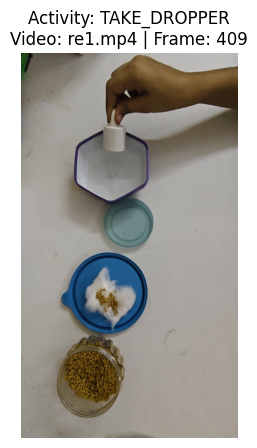

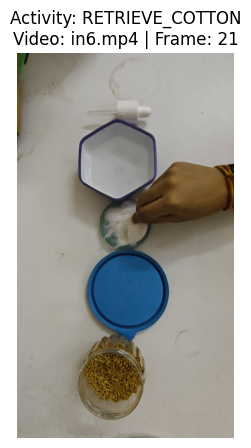

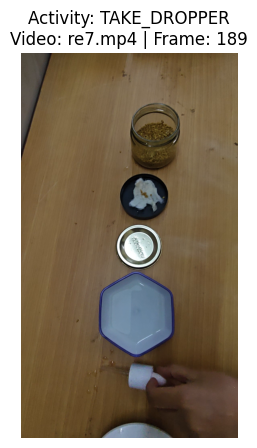

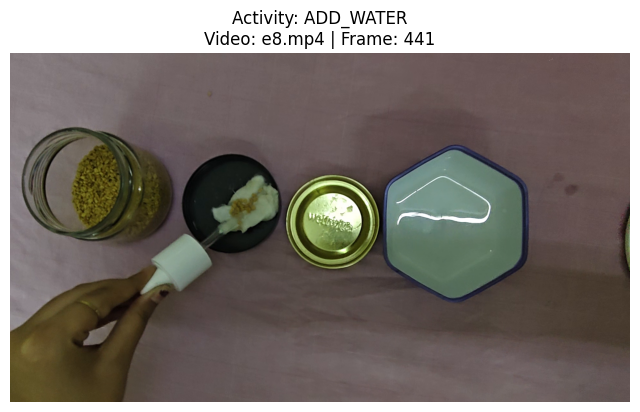

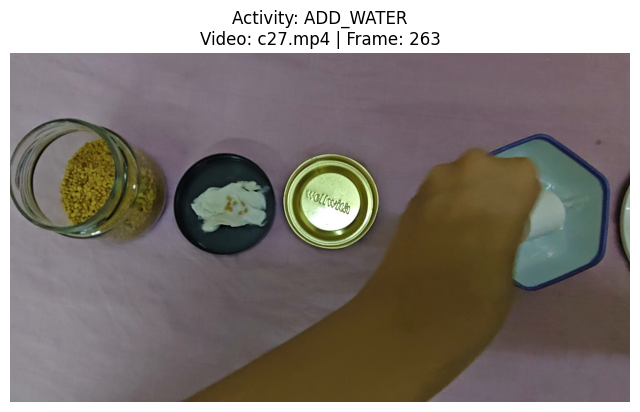

In [68]:
for _, row in sample_clips.iterrows():

    video_path = os.path.join(
        VIDEO_DIR,
        row["video_file"]
    )

    cap = cv2.VideoCapture(video_path)

    middle_frame = (
        int(row["start_frame"]) +
        int(row["end_frame"])
    ) // 2

    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)

    success, frame = cap.read()

    cap.release()

    if success:
        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(8, 5))
        plt.imshow(frame)
        plt.title(
            f"Activity: {row['activity']}\n"
            f"Video: {row['video_file']} | "
            f"Frame: {middle_frame}"
        )
        plt.axis("off")
        plt.show()

    else:
        print(
            "Could not read frame:",
            row["video_file"],
            middle_frame
        )